# Importing Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from scipy.sparse import csr_matrix

# A. Data Preprocessing

A. Importing the data

In [29]:
df = pd.read_csv('Vegetable_prices.csv')
df

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,0,Tomato Big(Nepali),6/16/13,Kg,35.0,40.0,37.5
1,1,Tomato Small(Local),6/16/13,Kg,26.0,32.0,29.0
2,2,Potato Red,6/16/13,Kg,20.0,21.0,20.5
3,3,Potato White,6/16/13,Kg,15.0,16.0,15.5
4,4,Onion Dry (Indian),6/16/13,Kg,28.0,30.0,29.0
...,...,...,...,...,...,...,...
2496,2496,Mustard Leaf,7/31/13,Kg,25.0,30.0,27.5
2497,2497,Fenugreek Leaf,7/31/13,Kg,30.0,35.0,32.5
2498,2498,Onion Green,7/31/13,Kg,30.0,35.0,32.5
2499,2499,Mushroom(Kanya),7/31/13,Kg,160.0,180.0,170.0


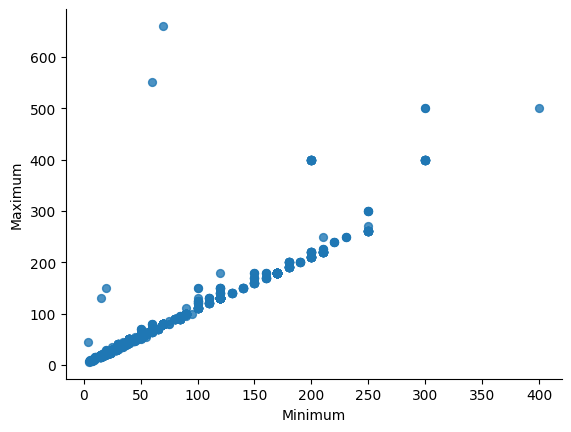

In [30]:
# @title Minimum vs Maximum

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Minimum', y='Maximum', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

Getting to know the data first

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SN         2501 non-null   int64  
 1   Commodity  2501 non-null   object 
 2   Date       2501 non-null   object 
 3   Unit       2501 non-null   object 
 4   Minimum    2498 non-null   float64
 5   Maximum    2498 non-null   float64
 6   Average    2501 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 136.9+ KB


In [32]:
df.describe()

,SN,Minimum,Maximum,Average
count,2501.000000,2498.000000,2498.000000,2501.000000
mean,1250.000000,64.215372,73.956365,69.126949
std,722.120835,55.827665,68.669151,61.390076
min,0.000000,4.000000,6.000000,5.500000
25%,625.000000,30.000000,35.000000,32.500000
50%,1250.000000,45.000000,50.000000,47.500000
75%,1875.000000,70.000000,80.000000,75.000000
max,2500.000000,400.000000,660.000000,450.000000


In [33]:
df.shape

(2501, 7)

In [34]:
df.head()

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,0,Tomato Big(Nepali),6/16/13,Kg,35.0,40.0,37.5
1,1,Tomato Small(Local),6/16/13,Kg,26.0,32.0,29.0
2,2,Potato Red,6/16/13,Kg,20.0,21.0,20.5
3,3,Potato White,6/16/13,Kg,15.0,16.0,15.5
4,4,Onion Dry (Indian),6/16/13,Kg,28.0,30.0,29.0


In [35]:
df.tail()

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
2496,2496,Mustard Leaf,7/31/13,Kg,25.0,30.0,27.5
2497,2497,Fenugreek Leaf,7/31/13,Kg,30.0,35.0,32.5
2498,2498,Onion Green,7/31/13,Kg,30.0,35.0,32.5
2499,2499,Mushroom(Kanya),7/31/13,Kg,160.0,180.0,170.0
2500,2500,Asparagus,7/31/13,Kg,150.0,180.0,165.0


In [36]:
df.isna()

,SN,Commodity,Date,Unit,Minimum,Maximum,Average
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2496,False,False,False,False,False,False,False
2497,False,False,False,False,False,False,False
2498,False,False,False,False,False,False,False
2499,False,False,False,False,False,False,False


In [37]:
df.isna().sum()

SN           0
Commodity    0
Date         0
Unit         0
Minimum      3
Maximum      3
Average      0
dtype: int64

B. CLeaning the data

In [38]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [39]:
#fill the missing data using simple imputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imputer.fit(x[:,1:3])
x[:,1:3] = imputer.transform(x[:,1:3])

In [40]:
print(x)

[[0 'Tomato Big(Nepali)' '6/16/13' 'Kg' 35.0 40.0]
 [1 'Tomato Small(Local)' '6/16/13' 'Kg' 26.0 32.0]
 [2 'Potato Red' '6/16/13' 'Kg' 20.0 21.0]
 ...
 [2498 'Onion Green' '7/31/13' 'Kg' 30.0 35.0]
 [2499 'Mushroom(Kanya)' '7/31/13' 'Kg' 160.0 180.0]
 [2500 'Asparagus' '7/31/13' 'Kg' 150.0 180.0]]


In [41]:
print(y)

[ 37.5  29.   20.5 ...  32.5 170.  165. ]


C. Split into training and test sets

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 0)

In [43]:
print(x_train)

[[161 'French Bean(Local)' '6/18/13' 'Kg' 30.0 35.0]
 [1257 'Mint' '7/10/13' 'Kg' 120.0 130.0]
 [249 'Cress Leaf' '6/19/13' 'Kg' 40.0 45.0]
 ...
 [763 'Neuro' '6/30/13' 'Kg' 50.0 60.0]
 [835 'Lettuce' '7/1/13' 'Kg' 50.0 60.0]
 [1653 'Pumpkin' '7/17/13' 'Kg' 18.0 20.0]]


In [44]:
print(x_test)

[[53 'Pomegranate' '6/16/13' 'Kg' 200.0 220.0]
 [2392 'Chilli Green' '7/29/13' 'Kg' 35.0 40.0]
 [2311 'Apple(Jholey)' '7/28/13' 'Kg' 100.0 110.0]
 ...
 [1259 'Maize' '7/10/13' '1 Pc' 6.0 7.0]
 [2125 'Tomato Big(Nepali)' '7/25/13' 'Kg' 50.0 55.0]
 [444 'Potato White' '6/25/13' 'Kg' 17.0 18.0]]


# B. Model Building

A. Build the model

In [45]:

# Handle non-numerical data
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore')
x_train_encoded = ohe.fit_transform(x_train[:, [1, 2, 3, 4, 5]])
x_test_encoded = ohe.transform(x_test[:, [1, 2, 3, 4, 5]])

# Extract numerical features
x_train_numerical = x_train[:, 0].reshape(-1, 1)
x_test_numerical = x_test[:, 0].reshape(-1, 1)


In [46]:
# Feature Scaling for numerical features
sc = StandardScaler()
x_train = sc.fit_transform(x_train_numerical)
x_test = sc.transform(x_test_numerical)


In [47]:
print(x_train)

[[-1.50113385]
 [ 0.01910245]
 [-1.37907108]
 ...
 [-0.66611354]
 [-0.56624401]
 [ 0.56838491]]


In [48]:
print(x_test)

[[-1.65093815e+00]
 [ 1.59343475e+00]
 [ 1.48108152e+00]
 [-7.14661235e-01]
 [-5.45437851e-01]
 [ 5.43417528e-01]
 [ 2.41034760e-01]
 [-1.73701238e-01]
 [ 1.16482799e+00]
 [-7.49338158e-01]
 [ 1.60453137e+00]
 [-4.19289309e-02]
 [-1.27226616e+00]
 [-2.36119699e-01]
 [-3.30440929e-01]
 [ 1.20782737e+00]
 [ 1.40479229e+00]
 [-3.24892622e-01]
 [-3.62343698e-01]
 [-1.26671785e+00]
 [ 1.02473322e+00]
 [ 1.44640460e+00]
 [-2.02829853e-01]
 [-5.87050159e-01]
 [ 1.60314429e+00]
 [-1.67867969e+00]
 [-5.86493109e-03]
 [-2.56925853e-01]
 [-1.45397323e+00]
 [ 8.06962142e-01]
 [ 7.47317834e-01]
 [ 1.19950491e+00]
 [ 9.42895679e-01]
 [ 7.34834142e-01]
 [-1.14465508e+00]
 [ 1.66972398e+00]
 [ 9.91443371e-01]
 [-6.73048928e-01]
 [ 1.64475660e+00]
 [ 4.83773220e-01]
 [-1.26255662e+00]
 [ 4.50483374e-01]
 [ 3.22872298e-01]
 [-4.47030847e-02]
 [-1.10997816e+00]
 [-8.89432926e-01]
 [ 1.23002060e+00]
 [-8.39498157e-01]
 [ 2.86808298e-01]
 [ 1.14402183e+00]
 [ 8.01338377e-02]
 [-2.31958468e-01]
 [ 1.2799553

B. Train the model

In [49]:
# Combine encoded categorical features and scaled numerical features
from scipy.sparse import hstack
x_train_final = hstack((x_train, x_train_encoded))
x_test_final = hstack((x_test, x_test_encoded))

In [50]:
# Training the Multiple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train_final, y_train)


LinearRegression()

Using 2 algorithm and Create 3 sample predicityon in each algorithm

In [51]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(x_train_final, y_train)

# Convert coo_matrix to csr_matrix for slicing
x_test_final_csr = csr_matrix(x_test_final)

In [52]:
# 2. Decision Tree Regression
dt_model = DecisionTreeRegressor()
dt_model.fit(x_train_final, y_train)


DecisionTreeRegressor()

C. Make Predictions

In [53]:
# Linear Regression Predictions
lr_pred1 = lr_model.predict(x_test_final_csr[0])
lr_pred2 = lr_model.predict(x_test_final_csr[1])
lr_pred3 = lr_model.predict(x_test_final_csr[2])

print("Linear Regression Predictions:")
print("Prediction 1:", lr_pred1)
print("Prediction 2:", lr_pred2)
print("Prediction 3:", lr_pred3)

Linear Regression Predictions:
Prediction 1: [209.95538257]
Prediction 2: [37.48191848]
Prediction 3: [104.94756436]


In [54]:
# Decision Tree Regression Predictions
dt_pred1 = dt_model.predict(x_test_final_csr[0])
dt_pred2 = dt_model.predict(x_test_final_csr[1])
dt_pred3 = dt_model.predict(x_test_final_csr[2])

print("\nDecision Tree Regression Predictions:")
print("Prediction 1:", dt_pred1)
print("Prediction 2:", dt_pred2)
print("Prediction 3:", dt_pred3)


Decision Tree Regression Predictions:
Prediction 1: [210.]
Prediction 2: [37.5]
Prediction 3: [105.]




Both Linear Regression and Decision Tree Regression models were trained and used to make predictions.
The predictions from both models provide estimates for the target variable based on the input features.
The choice of the best model depends on the specific requirements of the problem and the characteristics of the data
Further evaluation metrics and model comparison techniques can be used to determine the most suitable model.
It is important to consider factors such as model complexity, interpretability, and performance on unseen data when making a final decision.